# 1.) MZI MODEL

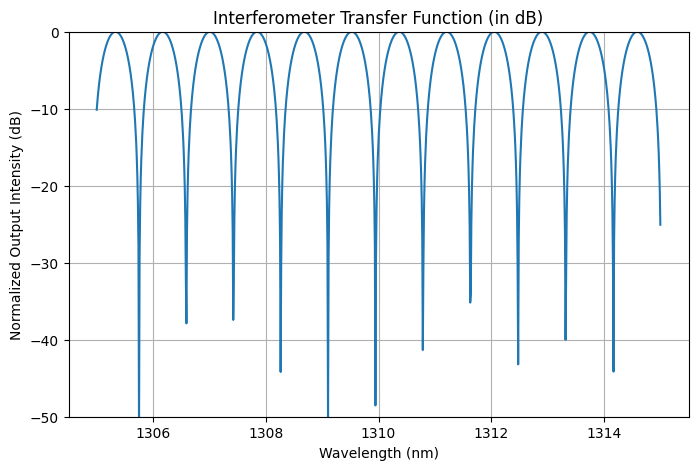

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as consts 



# Constants
c = consts.c
deltaL = 2.513371658045423e-3 # (m) 
n = 2.4337               # Base refractive index
dn_dt = 1e-5          # Thermo-optic coefficient (change of n with T)
delta_T1 = 0          # Temperature change in arm 1
delta_T2 = 0          # Temperature change in arm 2 (example, degrees C)
alpha1 = 0            
alpha2 = 0
Ii = 1                # Input intensity (normalized)

# Model parameters 
n_g = 4.77116

# Interferometer Settings
fsr_target = 25e9            # 25 GHz target FSR
delta_L = c / (n_g * fsr_target)  # Path length difference (m)

L1 = 2/3*deltaL             # Length of arm 1 (m)
L2 = 1/3*deltaL             # Length of arm 2 (m)

# Wavelength sweep (in meters)
wavelengths = np.linspace(1305e-9, 1315e-9, 1000)  # 1500 nm to 1600 nm

# Beta calculation
def beta(n, dn_dt, delta_T, wavelength):
    return (2 * np.pi / wavelength) * (n + dn_dt * delta_T)

# Calculate beta1 and beta2
beta1 = beta(n, dn_dt, delta_T1, wavelengths)
beta2 = beta(n, dn_dt, delta_T2, wavelengths)

# Transfer function: Io/Ii
transfer_function = 0.5 * (1 + np.cos(beta1 * L1 - beta2 * L2))
transfer_function_db = 10 * np.log10(np.clip(transfer_function, 1e-10, None))

# Plotting
plt.figure(figsize=(8,5))
plt.plot(wavelengths * 1e9, transfer_function_db)
plt.title('Interferometer Transfer Function (in dB)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Output Intensity (dB)')
plt.grid(True)
plt.ylim(-50, 0)  # Set dB range for better visibility
plt.show()

# C1 Data 

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import scipy.io
import matplotlib.pyplot as plt
